<center>

# Analytical calculations for Incoherent test

#### Author: Daniel Lomholt Christensen

</center>

In [98]:
import numpy as np
import matplotlib.pyplot as plt
import mcstasscript as ms
import pyFAI as pf

#### Analytical form factor of sphere solution


In [165]:
def P_sphere(q, R):
    res = 3*(np.sin(q*R) - q*R*np.cos(q*R) )/ (q*R)**3
    return res

def dSigdW(q, R, phi, drho):
    V = 4/3 * np.pi * R**3 
    return phi * drho**2 * V * P_sphere(q,R)**2

def w_att(l_full, mu_a, delta_rho, phi, R, lam):
    Qmind = 0.0000001
    Qmaxd = 100
    qmin = 0

    Isq = 0

    Qminl = np.log10 (Qmind)
    Qmaxl = np.log10 (Qmaxd)
    istp = np.floor((Qmaxl - Qminl) * 300.0 + 0.5)
    step = (np.log10 (min(Qmaxd, 4.0 * np.pi / lam)) - Qminl) / istp
    print(istp)
    for k in range(int(istp)):
        qmax = pow (10.0, Qminl + k * step)
        q = 0.5 * (qmin + qmax)
        Isq += dSigdW (q, R, phi, delta_rho) * q * (qmax - qmin)
        qmin = qmax

    print(f"Integrated coherent scattering cross section at 4 angs is {Isq:.4g}\n")
    v = 3956 / lam
    V2K = 1.58825361e-3
    k0 = v * V2K
    Isq *= 2 * np.pi / (k0**2)
    print(2 * np.pi / (k0**2))
    return np.exp(-l_full * 1.00175 * (mu_a * 2200/v + Isq))

def n_measured(flux, dist, solid, sigma_att, phi, delta_rho, q, R, lam):

    att_factor = w_att(dist, sigma_att, delta_rho, phi, R, lam)

    
    dsdw = dSigdW(q, R, phi, delta_rho)
    
    result = flux * dist * solid * att_factor * dsdw
    
    # print(f"flux={flux:.4g} dist = {dist:.4g} solid = {solid:.4g} att = {att_factor:.4g}\t product = { dist * solid * att_factor * dsdw}")
    for i,k in zip(q, dsdw):
        print(f"q={i}\t dsdw={k}")
        
    return result


In [166]:
# Load in the sans data
data = ms.load_data("../data/sans")
data_andreas = ms.load_data("../data/sans_andreas")
# The incoming flux is in the first monitor, converted into /cm^2
print(data[2].name, data[4].name)
flux = data[2].metadata.total_I# n/s
data = data[4] # And restrict ourselves to the last monitor
data_andreas = data_andreas[4] # And restrict ourselves to the last monitor


# Calculate uncertainty in energy
wavelength = 1/np.sqrt(5)/0.11056
d = 0.475
dwavelength = 1/np.sqrt(5-d)/0.11056
print(dwavelength/wavelength)


# detector = pf.detectors.Detector(100e-5, 100e-5)
detector = pf.detector_factory("detector")
detector.set_pixel1(1/1000)
detector.set_pixel2(1/1000)

# Set the azimuthal integrator
ai = pf.AzimuthalIntegrator(dist=4.99999, detector=detector)


# ai = pf.integrator.azimuthal.AzimuthalIntegrator(dist=5, detector=detector)
wavelength = 1/np.sqrt(5)/0.11056
ai.set_wavelength(wavelength*1e-10)
ai.poni1  = 0.5
ai.poni2 = 0.5
two_theta, I, E = ai.integrate1d(data.Intensity, 700, variance=data.Error**2, correctSolidAngle=True, unit="2th_deg") 
_, I_andreas, E_andreas = ai.integrate1d(data_andreas.Intensity, 700, variance=data_andreas.Error**2,correctSolidAngle=True, unit="2th_deg") 
q = np.sin((two_theta)*np.pi/180/2)*4*np.pi/wavelength
# result = ai.integrate2d(data.Intensity, 100)


dist = 0.001 # m
# Solid is the solid angle of each bin on the 
solid = 4 * 10**(-8)#(np.atan(0.5/5)*2)**2
print(solid)
delta_rho = 5 # fm/AA^3
phi = 1e-2 # Unit less

R = 100 # AA

sigma_att = 0.5 # m^-1
anal = n_measured(flux, dist, solid, sigma_att, phi,delta_rho, q, R, wavelength)




2026-08-26 09:45:21,196 WARNING:Function AzimuthalIntegrator is deprecated since pyFAI version 0.16. Use 'pyFAI.integrator.azimuthal.AzimuthalIntegrator' instead.
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/tqv636/miniforge3/envs/mcstas/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/tqv636/miniforge3/envs/mcstas/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/tqv636/miniforge3/envs/mcstas/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/Users/tqv636/miniforge3/envs/mcstas/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/Users/tqv636/miniforge3/envs/mcstas/lib/python3.12/asyncio/base_events.py", line 645, in run_forever
    self._run_onc

pre_samp_det psd_det
1.0511766624552734
4e-08
2700.0
Integrated coherent scattering cross section at 4 angs is 235.6

2.6041232549914746
q=0.00015587639239868938	 dsdw=1047146.6637959344
q=0.00046762917562637326	 dsdw=1046739.640898895
q=0.0007793819541449726	 dsdw=1045926.0019209773
q=0.0010911347248150978	 dsdw=1044706.5599119058
q=0.0014028874844973591	 dsdw=1043082.532982127
q=0.0017146402300523668	 dsdw=1041055.5425509759
q=0.0020263929583407324	 dsdw=1038627.6110136895
q=0.002338145666223066	 dsdw=1035801.1588341108
q=0.002649898350559979	 dsdw=1032579.0010666577
q=0.0029616510082120825	 dsdw=1028964.3433142536
q=0.0032734036360399883	 dsdw=1024960.7771294524
q=0.003585156230904308	 dsdw=1020572.274866534
q=0.0038969087896656538	 dsdw=1015803.1839939249
q=0.004208661309184638	 dsdw=1010658.2208768302
q=0.004520413786321874	 dsdw=1005142.4640409251
q=0.0048321662179379755	 dsdw=999261.3469291306
q=0.005143918600893556	 dsdw=993020.6501640199
q=0.005455670932049229	 dsdw=986426.493

39952.727 40321.694758969345


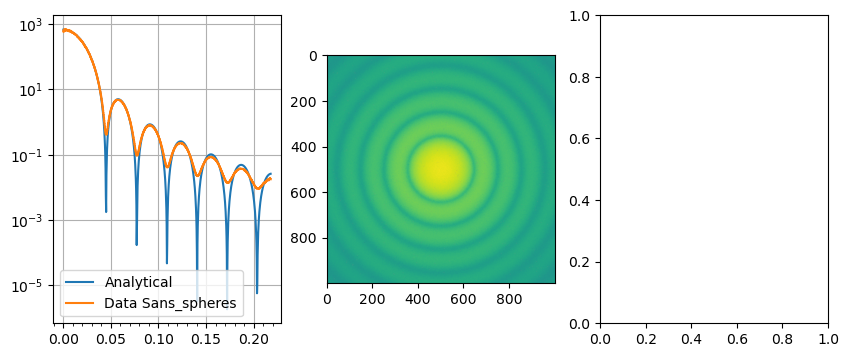

In [167]:
fig, ax = plt.subplots(ncols=3, figsize=(10,4))


ax[0].set(yscale="log")
ax[0].plot(q,anal, label="Analytical")
# q = np.insert(q,0,1e-3)[:-1]
ax[0].step(q, I,label="Data Sans_spheres")
# ax[0].step(q, I_andreas,label="Data SANS_spheres2")



# Set legends and labels
ax[0].legend()
ax[0].grid(True, which='major')
ax[0].minorticks_on()
# ax[0].set(xlabel="Q", ylabel="I", ylim=(1e-6,1e1))

ax[1].imshow(data.Intensity,  norm="log")

# ax[2].imshow(result[0], norm="log")
print(I.sum(), anal.sum())

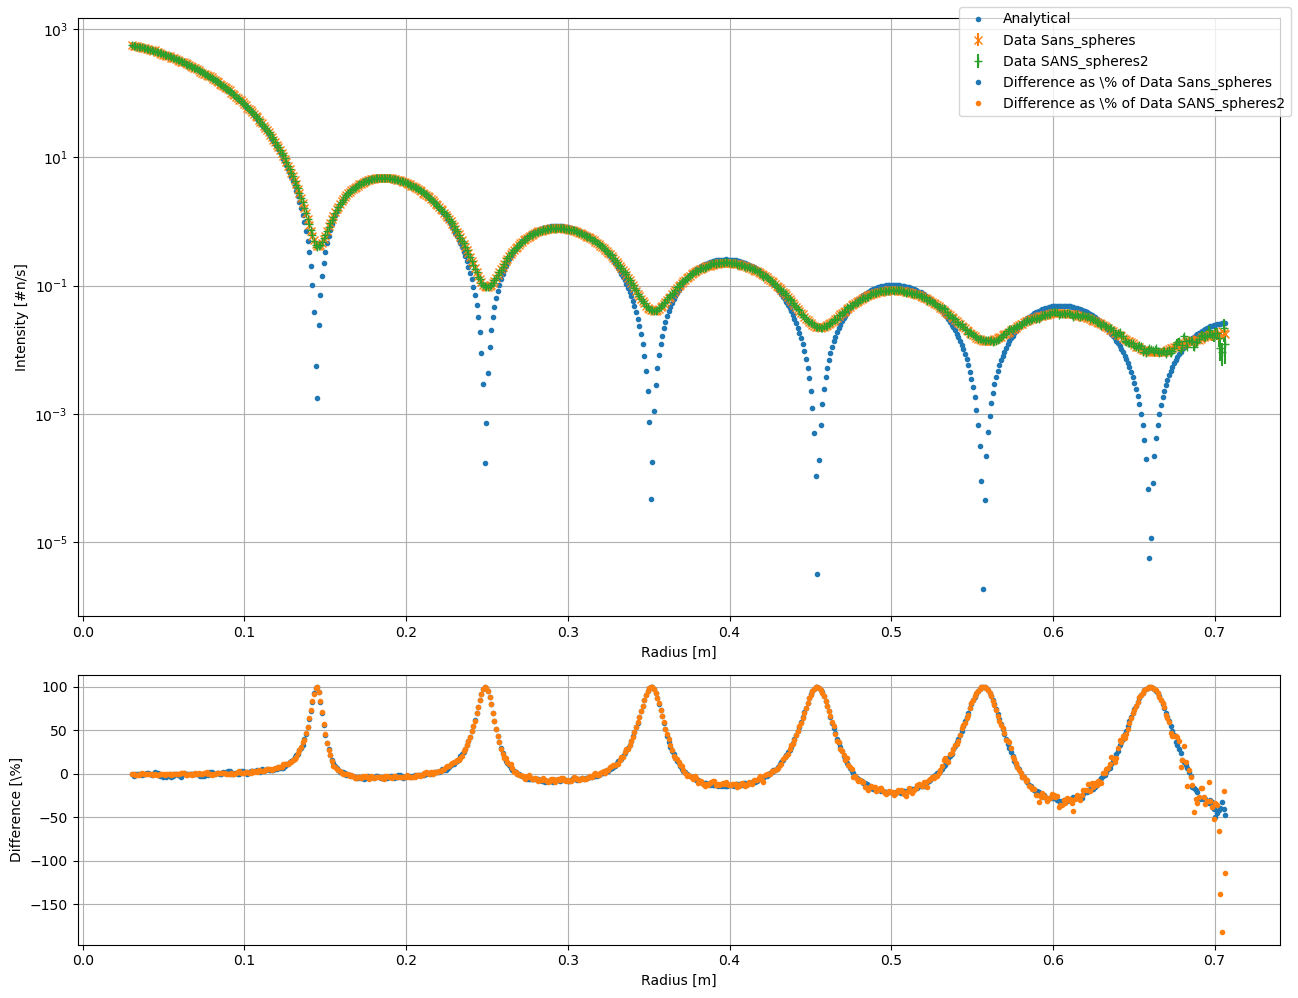

In [168]:
fig, ax = plt.subplot_mosaic([['main', 'main'],
                              ['main', 'main'],
                              ['diff', 'diff']],
                             figsize=(13,10))

q = np.sin((two_theta)*np.pi/180/2)*4*np.pi/wavelength
             
                       

start_idx = 30
r = 5 * np.tan(two_theta*np.pi/180)
r = r [start_idx:]

ax['main'].set(yscale="log")
ax['main'].plot(r,anal[start_idx:], '.',label="Analytical")
# q = np.insert(q,'main',1e-3)[:-1]
ax['main'].errorbar(r, I[start_idx:], E[start_idx:], fmt='x', label="Data Sans_spheres")
ax['main'].errorbar(r, I_andreas[start_idx:], E_andreas[start_idx:], fmt='+' ,label="Data SANS_spheres2")

# Set legends and labels

ax['main'].grid(True, which='major')
ax['main'].set(xlabel="Radius [m]", ylabel="Intensity [#n/s]", 
            #    ylim=(7e-37,7.25e-37)
               )

# I_cum = np.cumsum(I[start_idx:])
# I_and_cum = np.cumsum(I_andreas[start_idx:])
# anal_cum = np.cumsum(anal[start_idx:])

# I_cum_diff = I_cum - anal_cum
# I_and_cum_diff = I_and_cum - anal_cum

# ax['diff'].plot(r, I_cum_diff/I_cum * 100,'.b',markersize=2, label=r'Difference as \% of Data Sans_spheres')
# ax['diff'].plot(r, I_and_cum_diff/I_and_cum * 100,'.',markersize=2, label=r'Difference as \% of Data SANS_spheres2')
I_diff = (I - anal)/I
I_diff_andreas = (I_andreas - anal)/I_andreas
ax['diff'].plot(r,  I_diff[start_idx:] * 100,'.', label=r'Difference as \% of Data Sans_spheres')
ax['diff'].plot(r, I_diff_andreas[start_idx:] * 100,'.', label=r'Difference as \% of Data SANS_spheres2')
# ax['diff'].plot(r,  (I[start_idx:] - I_andreas[start_idx:])/I[start_idx:],'.b',markersize=2, label=r'Difference as \% of Data Sans_spheres')


# ax['diff'].set(yscale="log")
ax['diff'].set(xlabel="Radius [m]", ylabel=r"Difference [\%]", 
               # ylim=(-0.2, 0.1)
               )
ax['diff'].grid(True)
fig.legend()

fig.tight_layout()